In [1]:
import numpy as np
import ROOT
 
import matplotlib.pyplot as plt
import mplhep as hep

In [ ]:
#%pip install mplhep

There are many ways to graph an object. We can either create a .root file, and then open that file using terminal commands.

\>> root 

\>> new TBrowser

Then find and select the file.

In [ ]:
# Open the file to write the histogram to
with ROOT.TFile.Open("outfile_uhi.root", "RECREATE") as outFile:
    # Create the histogram object
    # There are several constructors you can use (see TH1). In this example we use the
    # simplest one, accepting a number of bins and a range.
    histogram = ROOT.TH1D("histogram", "My first ROOT histogram", nbinsx=30, xlow=0.0, xup=10.0)
 
    # Fill the histogram by passing a NumPy array. In this simple example we use a fake set of data.
    # The 'D' in TH1D stands for 'double', so we fill the histogram with doubles.
    # In general you should prefer TH1D over TH1F unless you have a very specific reason
    # to do otherwise.
    values = np.array([1, 2, 3, 3, 3, 4, 3, 2, 1, 0])
    counts, edges = np.histogram(values, bins=30, range=(0.0, 10.0))
    histogram[...] = counts
 
    # Write the histogram to `outFile`.
    outFile.WriteObject(histogram, histogram.GetName())
 
    # When `with` block exits, `outFile` will close itself and write its contents to disk.

Alternativley we can draw objects directly in notebooks/IDEs

In [ ]:
histogram = ROOT.TH1D("histogram", "My first ROOT histogram", nbinsx=30, xlow=0.0, xup=10.0)
values = np.array([1, 2, 3, 3, 3, 4, 3, 2, 1, 0])
counts, edges = np.histogram(values, bins=30, range=(0.0, 10.0))
histogram[...] = counts

c = ROOT.TCanvas("c")
c.Draw()
histogram.Draw()

In [ ]:
c.Close()

We can obviously fill a histogram with random data rather than manually doing so as we did above. We can create a gaussian either using random data or using the ROOT's built in gaus keyword.

And rather than graphing them seperatley, we can simply place them on the same canvas.

In [ ]:
np.random.seed(0)

# Create 1-D histogram to be filled with a gaussian distribution.
h1d = ROOT.TH1D("h1d_rand", "Test Random Numbers", nbinsx=200, xlow=0., xup=10.)
values = np.random.normal(0.0, 1.0, 10000)
h1d.Fill(values)
c1 = ROOT.TCanvas("c1")

h1d_gaus = ROOT.TH1D("h1d_gaus", "Test Random Numbers", nbinsx=200, xlow=-10., xup=10.)
h1d_gaus.FillRandom("gaus",10000)
c2 = ROOT.TCanvas("c2")

In [ ]:
window = ROOT.TCanvas("window")
window.Divide(1,2);  # 1 column, 2 rows
window.Draw()

window.cd(1)
h1d.Draw()

window.cd(2)
h1d_gaus.Draw()

In [ ]:
window.Close()

Of course, we can also simply define our own formulas to graph. 

The only unintuitive part for me is the (0) and the [3] in the sqroot line. The (0) means start taking parameters from the 0th parameter onwards. Since gaus takes in 3 parameters, it takes in parameters 0,1,2. Likewise the [3] is just a placeholder that takes on the value of the third parameter.

In [6]:
# Create a user defined formula. This function may be N-dimensional, and can can reference other formulas.
form_sinc = ROOT.TFormula("form_sinc", "abs(sin(x)/x)")

# Create 1D function based on the formula above and the predefined gaus formula.
rangeMin = -10
rangeMax = 10
sqroot = ROOT.TF1("sqroot", "x*gaus(0) + [3]*form_sinc", rangeMin, rangeMax)
# Set parameters to the functions "gaus" and "form_sinc".
gaus_scale = 10.0  # [0]  gaus has parameters scale (height) mean (center) and variance (width)
gaus_mean = 5.0  # [1]
gaus_var = 1.0  # [2]
form_sinc_scale = 20.0  # [3] form_sinc will get multiplied by this scalar
form_sinc_freq = 10.
sqroot.SetParameters(gaus_scale, gaus_mean, gaus_var, form_sinc_scale, form_sinc_freq)

# Create and fill 1D histogram with the sqroot function values
h1d = ROOT.TH1D("h1d", "Test random numbers", 200, rangeMin, rangeMax)
 
# Use our user-defined function to fill the histogram with random values sampled from it.
h1d.Fill(np.array([sqroot.GetRandom() for _ in range(10000)]))

c = ROOT.TCanvas("c")
c.Draw()
h1d.Draw()

Warning in <TROOT::Append>: Replacing existing TH1: h1d (Potential memory leak).


In order to use a formula with parameters inside another formula, the parameters seem to require a unique name, not just an index integer. 

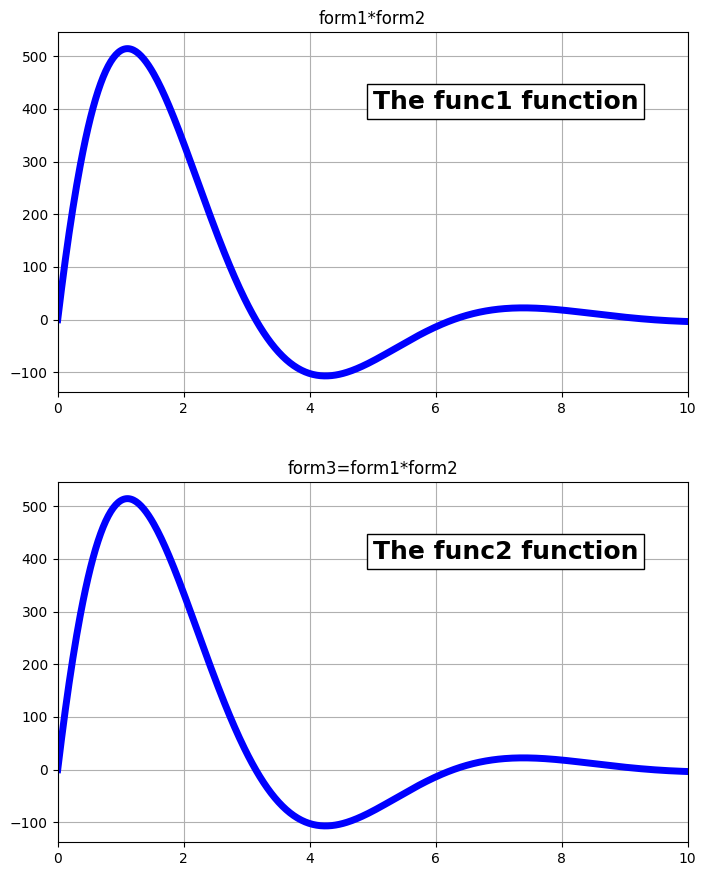

In [16]:
# Define 2 formulas with unique parameter names
form1 = ROOT.TFormula("form1", "[p0]*sin(x)")
form2 = ROOT.TFormula("form2", "[p1]*exp(-[p2]*x)")
# Define a formula that refers to other formulas
form3 = ROOT.TFormula("form3", "form1(x, [p0]) * form2(x,[p1],[p2])")  ############## Define formula with formulas

# Define a func1 = form1*2 and onther func2=form3 where form3=form1*form2
rangeMin = 0.0
rangeMax = 10.0
func1 = ROOT.TF1("func1", "form1*form2", rangeMin, rangeMax)
func1.SetParameters(10.0, 100., 0.5)

func2 = ROOT.TF1("func2", "form3", rangeMin, rangeMax)
func2.SetParameters(p0=10.0, p2=0.5, p1=100.)
 

# Create a canvas and draw graphs
plt.figure(figsize=(7, 9))
 
# Split the canvas into two sections to plot both functions
plt.axes([0.05, 0.55, 0.90, 0.40]) #left, bottom, width, height
x = np.linspace(rangeMin, rangeMax, 500)
plt.plot(x, [func1.Eval(xi) for xi in x], "b-", lw=5)
plt.grid()
plt.title("form1*form2")
plt.text(5, 400, "The func1 function", fontsize=18, weight="bold", bbox=dict(facecolor="white", edgecolor="black"))
plt.xlim(rangeMin, rangeMax)
plt.ylim()
 
plt.axes([0.05, 0.05, 0.90, 0.40])
x = np.linspace(rangeMin, rangeMax, 500)
plt.plot(x, [func2.Eval(xi) for xi in x], "b-", lw=5)
plt.grid()
plt.title("form3=form1*form2")
plt.text(5, 400, "The func2 function", fontsize=18, weight="bold", bbox=dict(facecolor="white", edgecolor="black"))
plt.xlim(rangeMin, rangeMax)
plt.ylim()
 
plt.show()

In [4]:
plt.close()